# Marketing A/B Testing & Conversion Analytics

### Project Overview

This project compares a **Control Campaign** and a **Test Campaign** to evaluate which marketing strategy performs better across **engagement, conversion, and cost efficiency**.

### Business Objective

Identify whether the Test Campaign delivers meaningful improvements over the Control Campaign and determine **where performance improves or drops across the marketing funnel**.

### Analysis Performed

- Campaign performance comparison
- Conversion funnel analysis
- CTR, CPC and CPA analysis
- Stage-wise conversion rate analysis
- Daily performance trends
- Statistical significance testing using **Welch's t-test**
- Business insights and campaign recommendation

### Tools

**Python | Pandas | NumPy | Matplotlib | Seaborn | SciPy | Power BI**

### Dataset

Daily marketing campaign data covering **August 2019**, tracking the journey from **Impressions → Clicks → View Content → Add to Cart → Purchase**.

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
import os
print(os.getcwd())

c:\Users\Isha\OneDrive\Desktop\AB-Testing-Marketing-Compaign\notebooks


In [147]:
from pathlib import Path
import pandas as pd

project_root = Path(r"C:\Users\Isha\OneDrive\Desktop\AB-Testing-Marketing-Compaign")

control = pd.read_csv(project_root / "data" / "raw" / "control_group.csv", sep=";")
test = pd.read_csv(project_root / "data" / "raw" / "test_group.csv", sep=";")

print("Control Campaign:", control.shape)
print("Test Campaign:", test.shape)

Control Campaign: (30, 10)
Test Campaign: (30, 10)


In [148]:
print("Control columns:")
print(control.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Control columns:
['Campaign Name', 'Date', 'Spend [USD]', '# of Impressions', 'Reach', '# of Website Clicks', '# of Searches', '# of View Content', '# of Add to Cart', '# of Purchase']

Test columns:
['Campaign Name', 'Date', 'Spend [USD]', '# of Impressions', 'Reach', '# of Website Clicks', '# of Searches', '# of View Content', '# of Add to Cart', '# of Purchase']


In [149]:
control.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [150]:
test.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


In [151]:
control.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Campaign Name        30 non-null     str    
 1   Date                 30 non-null     str    
 2   Spend [USD]          30 non-null     int64  
 3   # of Impressions     29 non-null     float64
 4   Reach                29 non-null     float64
 5   # of Website Clicks  29 non-null     float64
 6   # of Searches        29 non-null     float64
 7   # of View Content    29 non-null     float64
 8   # of Add to Cart     29 non-null     float64
 9   # of Purchase        29 non-null     float64
dtypes: float64(7), int64(1), str(2)
memory usage: 3.2 KB


In [152]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Campaign Name        30 non-null     str  
 1   Date                 30 non-null     str  
 2   Spend [USD]          30 non-null     int64
 3   # of Impressions     30 non-null     int64
 4   Reach                30 non-null     int64
 5   # of Website Clicks  30 non-null     int64
 6   # of Searches        30 non-null     int64
 7   # of View Content    30 non-null     int64
 8   # of Add to Cart     30 non-null     int64
 9   # of Purchase        30 non-null     int64
dtypes: int64(8), str(2)
memory usage: 3.1 KB


In [153]:
print("Control missing values:")
print(control.isnull().sum())

print("\nTest missing values:")
print(test.isnull().sum())

Control missing values:
Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       1
Reach                  1
# of Website Clicks    1
# of Searches          1
# of View Content      1
# of Add to Cart       1
# of Purchase          1
dtype: int64

Test missing values:
Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       0
Reach                  0
# of Website Clicks    0
# of Searches          0
# of View Content      0
# of Add to Cart       0
# of Purchase          0
dtype: int64


In [154]:
control[control.isnull().any(axis=1)]

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [155]:
control_clean = control.dropna().copy()

print("Before cleaning:", control.shape)
print("After cleaning:", control_clean.shape)

Before cleaning: (30, 10)
After cleaning: (29, 10)


In [156]:
print("Control missing values:")
print(control_clean.isnull().sum())

print("\nTest missing values:")
print(test.isnull().sum())

Control missing values:
Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       0
Reach                  0
# of Website Clicks    0
# of Searches          0
# of View Content      0
# of Add to Cart       0
# of Purchase          0
dtype: int64

Test missing values:
Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       0
Reach                  0
# of Website Clicks    0
# of Searches          0
# of View Content      0
# of Add to Cart       0
# of Purchase          0
dtype: int64


In [157]:
control_clean["Date"] = pd.to_datetime(
    control_clean["Date"],
    format="%d.%m.%Y"
)

test["Date"] = pd.to_datetime(
    test["Date"],
    format="%d.%m.%Y"
)

In [158]:
print(control_clean["Date"].dtype)
print(test["Date"].dtype)

datetime64[us]
datetime64[us]


In [159]:
print("Control duplicate rows:", control_clean.duplicated().sum())
print("Test duplicate rows:", test.duplicated().sum())

Control duplicate rows: 0
Test duplicate rows: 0


In [160]:
print("Control unique dates:", control_clean["Date"].nunique())
print("Test unique dates:", test["Date"].nunique())

Control unique dates: 29
Test unique dates: 30


In [161]:
# Add campaign labels
control_clean["Campaign Type"] = "Control"
test["Campaign Type"] = "Test"

# Combine both campaigns
df = pd.concat([control_clean, test], ignore_index=True)

print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (59, 11)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,Campaign Type
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,Control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,Control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,Control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,Control
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,Control


In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Campaign Name        59 non-null     str           
 1   Date                 59 non-null     datetime64[us]
 2   Spend [USD]          59 non-null     int64         
 3   # of Impressions     59 non-null     float64       
 4   Reach                59 non-null     float64       
 5   # of Website Clicks  59 non-null     float64       
 6   # of Searches        59 non-null     float64       
 7   # of View Content    59 non-null     float64       
 8   # of Add to Cart     59 non-null     float64       
 9   # of Purchase        59 non-null     float64       
 10  Campaign Type        59 non-null     str           
dtypes: datetime64[us](1), float64(7), int64(1), str(2)
memory usage: 6.4 KB


In [163]:
print(df["Campaign Type"].value_counts())

Campaign Type
Test       30
Control    29
Name: count, dtype: int64


In [164]:
# Click-through rate
df["CTR (%)"] = (
    df["# of Website Clicks"] / df["# of Impressions"]
) * 100

# Cost per click
df["CPC (USD)"] = (
    df["Spend [USD]"] / df["# of Website Clicks"]
)

# Cost per purchase
df["CPA (USD)"] = (
    df["Spend [USD]"] / df["# of Purchase"]
)

# Click-to-purchase conversion rate
df["Purchase Conversion (%)"] = (
    df["# of Purchase"] / df["# of Website Clicks"]
) * 100

# View content to add-to-cart rate
df["View to Cart (%)"] = (
    df["# of Add to Cart"] / df["# of View Content"]
) * 100

# Add-to-cart to purchase rate
df["Cart to Purchase (%)"] = (
    df["# of Purchase"] / df["# of Add to Cart"]
) * 100

print("KPI columns created successfully.")

KPI columns created successfully.


In [165]:
# Total performance of each campaign

campaign_totals = df.groupby("Campaign Type")[
    [
        "Spend [USD]",
        "# of Impressions",
        "Reach",
        "# of Website Clicks",
        "# of Searches",
        "# of View Content",
        "# of Add to Cart",
        "# of Purchase"
    ]
].sum()

campaign_totals

,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
Campaign Type,,,,,,,,
Control,66818,3177233.0,2576503.0,154303.0,64418.0,56370.0,37700.0,15161.0
Test,76892,2237544.0,1604747.0,180970.0,72569.0,55740.0,26446.0,15637.0


In [166]:
# Overall funnel conversion rates

campaign_totals["CTR (%)"] = (
    campaign_totals["# of Website Clicks"]
    / campaign_totals["# of Impressions"]
) * 100

campaign_totals["Click to Purchase (%)"] = (
    campaign_totals["# of Purchase"]
    / campaign_totals["# of Website Clicks"]
) * 100

campaign_totals["View to Cart (%)"] = (
    campaign_totals["# of Add to Cart"]
    / campaign_totals["# of View Content"]
) * 100

campaign_totals["Cart to Purchase (%)"] = (
    campaign_totals["# of Purchase"]
    / campaign_totals["# of Add to Cart"]
) * 100

campaign_totals.round(2)

,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,CTR (%),Click to Purchase (%),View to Cart (%),Cart to Purchase (%)
Campaign Type,,,,,,,,,,,,
Control,66818,3177233.0,2576503.0,154303.0,64418.0,56370.0,37700.0,15161.0,4.86,9.83,66.88,40.21
Test,76892,2237544.0,1604747.0,180970.0,72569.0,55740.0,26446.0,15637.0,8.09,8.64,47.45,59.13


In [167]:
# Overall campaign efficiency metrics

campaign_totals["CPC (USD)"] = (
    campaign_totals["Spend [USD]"]
    / campaign_totals["# of Website Clicks"]
)

campaign_totals["CPA (USD)"] = (
    campaign_totals["Spend [USD]"]
    / campaign_totals["# of Purchase"]
)

campaign_totals.round(2)

,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,CTR (%),Click to Purchase (%),View to Cart (%),Cart to Purchase (%),CPC (USD),CPA (USD)
Campaign Type,,,,,,,,,,,,,,
Control,66818,3177233.0,2576503.0,154303.0,64418.0,56370.0,37700.0,15161.0,4.86,9.83,66.88,40.21,0.43,4.41
Test,76892,2237544.0,1604747.0,180970.0,72569.0,55740.0,26446.0,15637.0,8.09,8.64,47.45,59.13,0.42,4.92


In [168]:
final_kpi = campaign_totals[
    [
        "Spend [USD]",
        "# of Impressions",
        "Reach",
        "# of Website Clicks",
        "# of Purchase",
        "CTR (%)",
        "CPC (USD)",
        "CPA (USD)",
        "Click to Purchase (%)",
        "View to Cart (%)",
        "Cart to Purchase (%)"
    ]
].round(2)

final_kpi

,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Purchase,CTR (%),CPC (USD),CPA (USD),Click to Purchase (%),View to Cart (%),Cart to Purchase (%)
Campaign Type,,,,,,,,,,,
Control,66818,3177233.0,2576503.0,154303.0,15161.0,4.86,0.43,4.41,9.83,66.88,40.21
Test,76892,2237544.0,1604747.0,180970.0,15637.0,8.09,0.42,4.92,8.64,47.45,59.13


In [169]:
from pathlib import Path

Path("data/processed").mkdir(parents=True, exist_ok=True)

df.to_csv("data/processed/ab_testing_cleaned.csv", index=False)
print("Processed dataset saved successfully.")

Processed dataset saved successfully.


Exploratory Data Analysis & Funnel Analysis

Campaign totals comparison

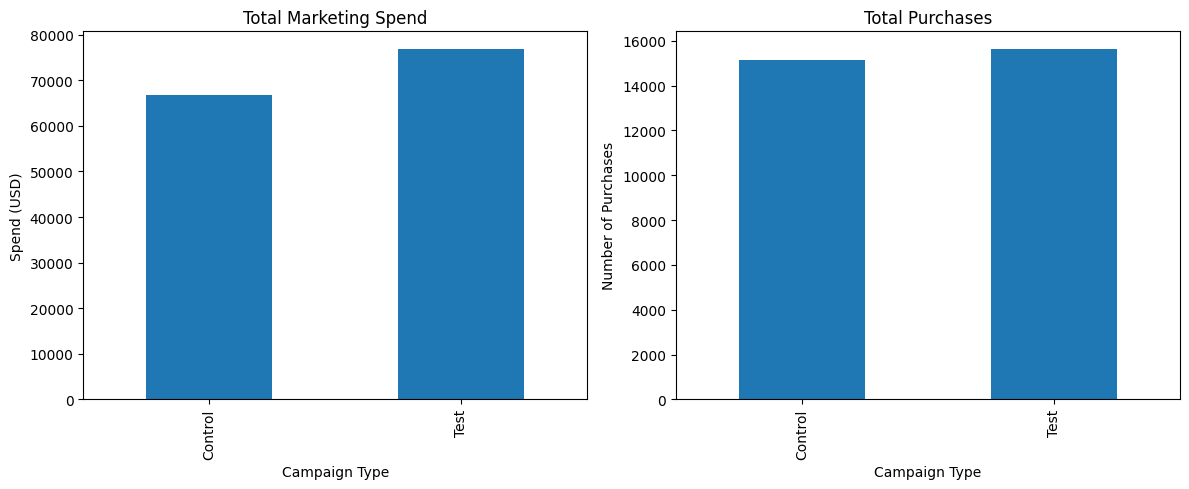

In [170]:
# Compare total purchases and spending

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

campaign_totals["Spend [USD]"].plot(
    kind="bar",
    ax=axes[0],
    title="Total Marketing Spend"
)

campaign_totals["# of Purchase"].plot(
    kind="bar",
    ax=axes[1],
    title="Total Purchases"
)

axes[0].set_ylabel("Spend (USD)")
axes[1].set_ylabel("Number of Purchases")

plt.tight_layout()
plt.show()

In [171]:
# Funnel stages

funnel = pd.DataFrame({
    "Control": [
        campaign_totals.loc["Control", "# of Impressions"],
        campaign_totals.loc["Control", "# of Website Clicks"],
        campaign_totals.loc["Control", "# of View Content"],
        campaign_totals.loc["Control", "# of Add to Cart"],
        campaign_totals.loc["Control", "# of Purchase"]
    ],
    
    "Test": [
        campaign_totals.loc["Test", "# of Impressions"],
        campaign_totals.loc["Test", "# of Website Clicks"],
        campaign_totals.loc["Test", "# of View Content"],
        campaign_totals.loc["Test", "# of Add to Cart"],
        campaign_totals.loc["Test", "# of Purchase"]
    ]
}, index=[
    "Impressions",
    "Website Clicks",
    "View Content",
    "Add to Cart",
    "Purchase"
])

funnel

,Control,Test
Impressions,3177233.0,2237544.0
Website Clicks,154303.0,180970.0
View Content,56370.0,55740.0
Add to Cart,37700.0,26446.0
Purchase,15161.0,15637.0


In [172]:
funnel_rates = pd.DataFrame({
    "Control": [
        campaign_totals.loc["Control", "CTR (%)"],
        campaign_totals.loc["Control", "View to Cart (%)"],
        campaign_totals.loc["Control", "Cart to Purchase (%)"],
        campaign_totals.loc["Control", "Click to Purchase (%)"]
    ],
    
    "Test": [
        campaign_totals.loc["Test", "CTR (%)"],
        campaign_totals.loc["Test", "View to Cart (%)"],
        campaign_totals.loc["Test", "Cart to Purchase (%)"],
        campaign_totals.loc["Test", "Click to Purchase (%)"]
    ]
}, index=[
    "Click-through Rate",
    "View to Cart",
    "Cart to Purchase",
    "Click to Purchase"
])

funnel_rates.round(2)

,Control,Test
Click-through Rate,4.86,8.09
View to Cart,66.88,47.45
Cart to Purchase,40.21,59.13
Click to Purchase,9.83,8.64


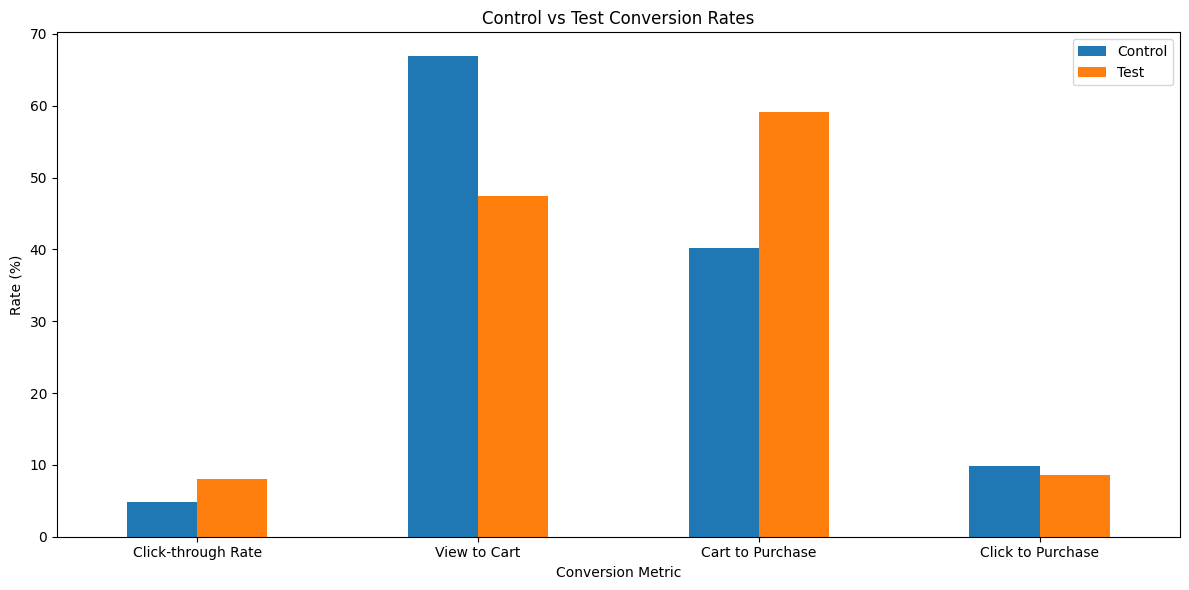

In [173]:
funnel_rates.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Control vs Test Conversion Rates")
plt.xlabel("Conversion Metric")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [174]:
# Calculate percentage-point difference: Test - Control

funnel_difference = (
    funnel_rates["Test"] - funnel_rates["Control"]
).round(2)

funnel_difference

Click-through Rate     3.23
View to Cart         -19.43
Cart to Purchase      18.91
Click to Purchase     -1.18
dtype: float64

Statistical A/B Testing

In [175]:
from scipy.stats import ttest_ind

In [176]:
# Separate daily KPI values by campaign

control_ctr = df[df["Campaign Type"] == "Control"]["CTR (%)"]
test_ctr = df[df["Campaign Type"] == "Test"]["CTR (%)"]

control_cpa = df[df["Campaign Type"] == "Control"]["CPA (USD)"]
test_cpa = df[df["Campaign Type"] == "Test"]["CPA (USD)"]

control_conversion = df[
    df["Campaign Type"] == "Control"
]["Purchase Conversion (%)"]

test_conversion = df[
    df["Campaign Type"] == "Test"
]["Purchase Conversion (%)"]

In [177]:
# Welch's t-test for unequal variances

ctr_stat, ctr_p = ttest_ind(
    control_ctr,
    test_ctr,
    equal_var=False
)

cpa_stat, cpa_p = ttest_ind(
    control_cpa,
    test_cpa,
    equal_var=False
)

conversion_stat, conversion_p = ttest_ind(
    control_conversion,
    test_conversion,
    equal_var=False
)

print("CTR p-value:", round(ctr_p, 4))
print("CPA p-value:", round(cpa_p, 4))
print("Purchase Conversion p-value:", round(conversion_p, 4))

CTR p-value: 0.0003
CPA p-value: 0.1946
Purchase Conversion p-value: 0.1428


In [178]:
statistical_results = pd.DataFrame({
    "Metric": [
        "CTR",
        "CPA",
        "Purchase Conversion"
    ],
    "Control Mean": [
        control_ctr.mean(),
        control_cpa.mean(),
        control_conversion.mean()
    ],
    "Test Mean": [
        test_ctr.mean(),
        test_cpa.mean(),
        test_conversion.mean()
    ],
    "p-value": [
        ctr_p,
        cpa_p,
        conversion_p
    ]
})

statistical_results.round(4)

,Metric,Control Mean,Test Mean,p-value
0,CTR,5.0959,10.2423,0.0003
1,CPA,5.0523,5.8996,0.1946
2,Purchase Conversion,11.4772,9.2312,0.1428


In [179]:
# Calculate relative changes from Control to Test

comparison = pd.DataFrame({
    "Metric": [
        "Spend",
        "Impressions",
        "Website Clicks",
        "Purchases",
        "CTR",
        "CPC",
        "CPA",
        "Click to Purchase"
    ],
    "Control": [
        campaign_totals.loc["Control", "Spend [USD]"],
        campaign_totals.loc["Control", "# of Impressions"],
        campaign_totals.loc["Control", "# of Website Clicks"],
        campaign_totals.loc["Control", "# of Purchase"],
        campaign_totals.loc["Control", "CTR (%)"],
        campaign_totals.loc["Control", "CPC (USD)"],
        campaign_totals.loc["Control", "CPA (USD)"],
        campaign_totals.loc["Control", "Click to Purchase (%)"]
    ],
    "Test": [
        campaign_totals.loc["Test", "Spend [USD]"],
        campaign_totals.loc["Test", "# of Impressions"],
        campaign_totals.loc["Test", "# of Website Clicks"],
        campaign_totals.loc["Test", "# of Purchase"],
        campaign_totals.loc["Test", "CTR (%)"],
        campaign_totals.loc["Test", "CPC (USD)"],
        campaign_totals.loc["Test", "CPA (USD)"],
        campaign_totals.loc["Test", "Click to Purchase (%)"]
    ]
})

comparison["Change (%)"] = (
    (comparison["Test"] - comparison["Control"])
    / comparison["Control"]
) * 100

comparison.round(2)

,Metric,Control,Test,Change (%)
0,Spend,66818.00,76892.00,15.08
1,Impressions,3177233.00,2237544.00,-29.58
2,Website Clicks,154303.00,180970.00,17.28
3,Purchases,15161.00,15637.00,3.14
4,CTR,4.86,8.09,66.54
5,CPC,0.43,0.42,-1.88
6,CPA,4.41,4.92,11.57
7,Click to Purchase,9.83,8.64,-12.06


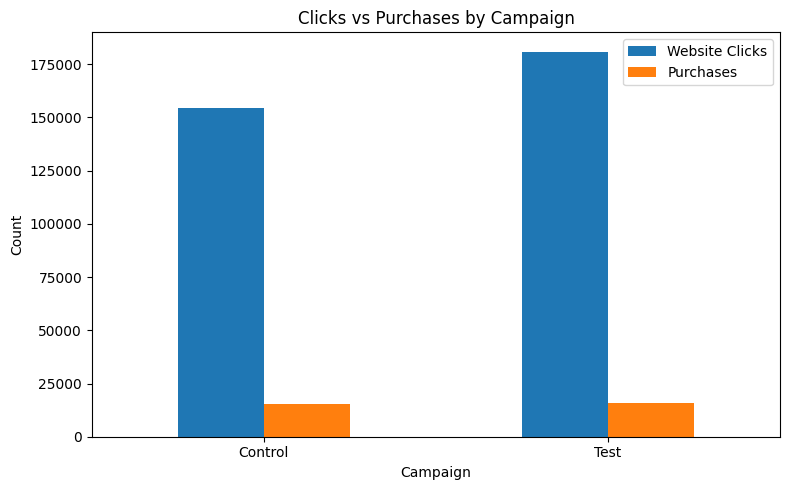

In [180]:
# Clicks vs Purchases

comparison = campaign_totals[
    ["# of Website Clicks", "# of Purchase"]
].copy()

ax = comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Clicks vs Purchases by Campaign")
ax.set_xlabel("Campaign")
ax.set_ylabel("Count")
ax.set_xticklabels(["Control", "Test"], rotation=0)
ax.legend(["Website Clicks", "Purchases"])

plt.tight_layout()

import os

visuals_folder = os.path.join(project_root, "visuals")
os.makedirs(visuals_folder, exist_ok=True)

plt.savefig(
    os.path.join(visuals_folder, "clicks_vs_purchases.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

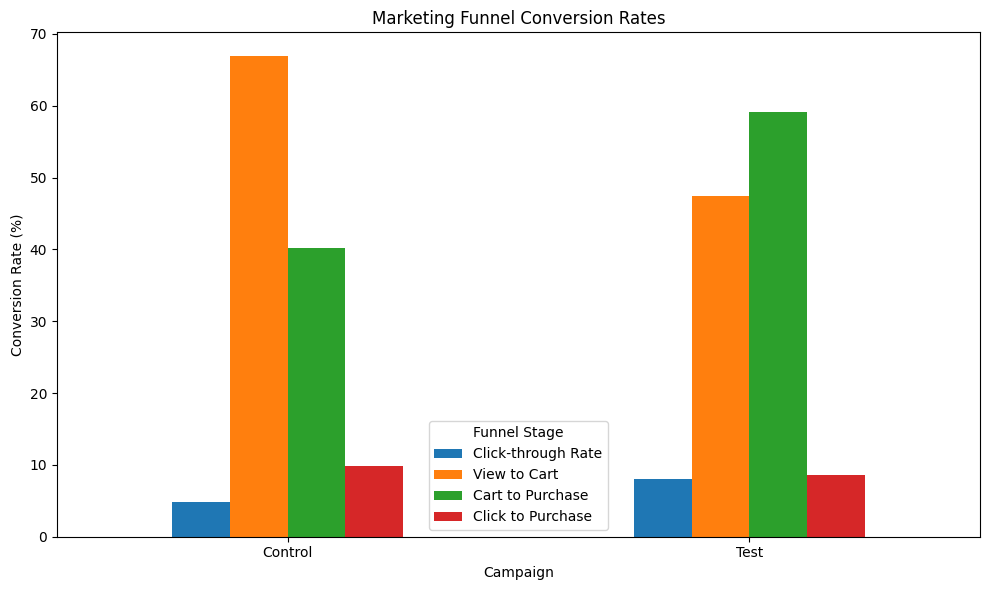

In [181]:
# Funnel Conversion Rates

ax = funnel_rates.T.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Marketing Funnel Conversion Rates")
ax.set_xlabel("Campaign")
ax.set_ylabel("Conversion Rate (%)")
ax.set_xticklabels(["Control", "Test"], rotation=0)

plt.legend(title="Funnel Stage")
plt.tight_layout()

# Save chart
import os

visuals_folder = r"C:\Users\Isha\OneDrive\Desktop\AB-Testing-Marketing-Compaign\visuals"

plt.savefig(
    os.path.join(visuals_folder, "funnel_conversion_rates.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

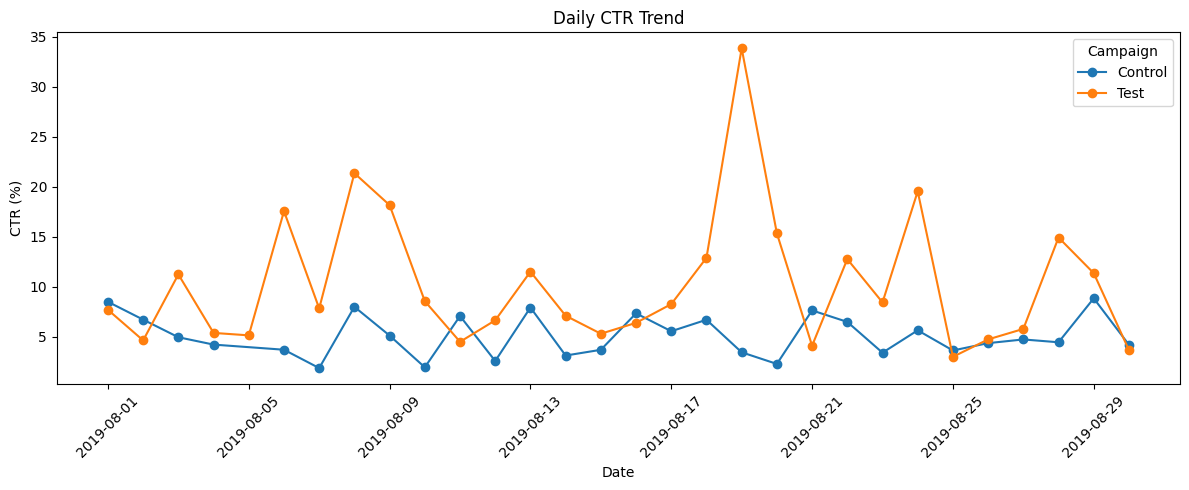

In [182]:
# Daily CTR Trend

plt.figure(figsize=(12, 5))

for campaign in ["Control", "Test"]:
    campaign_data = df[df["Campaign Type"] == campaign].sort_values("Date")
    
    plt.plot(
        campaign_data["Date"],
        campaign_data["CTR (%)"],
        marker="o",
        label=campaign
    )

plt.title("Daily CTR Trend")
plt.xlabel("Date")
plt.ylabel("CTR (%)")
plt.legend(title="Campaign")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(visuals_folder, "daily_ctr_trend.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

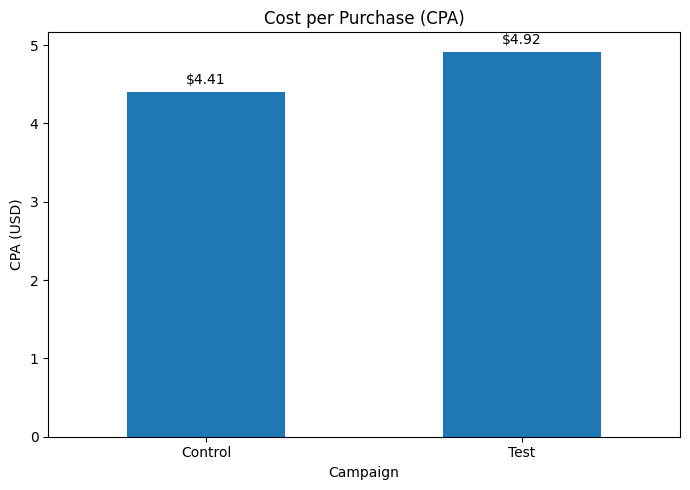

In [183]:
# CPA Comparison

cpa_values = campaign_totals["CPA (USD)"]

ax = cpa_values.plot(
    kind="bar",
    figsize=(7, 5)
)

ax.set_title("Cost per Purchase (CPA)")
ax.set_xlabel("Campaign")
ax.set_ylabel("CPA (USD)")
ax.set_xticklabels(["Control", "Test"], rotation=0)

for i, value in enumerate(cpa_values):
    ax.text(i, value + 0.1, f"${value:.2f}", ha="center")

plt.tight_layout()

import os

visuals_folder = r"C:\Users\Isha\OneDrive\Desktop\AB-Testing-Marketing-Compaign\visuals"

plt.savefig(
    os.path.join(visuals_folder, "cpa_comparison.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

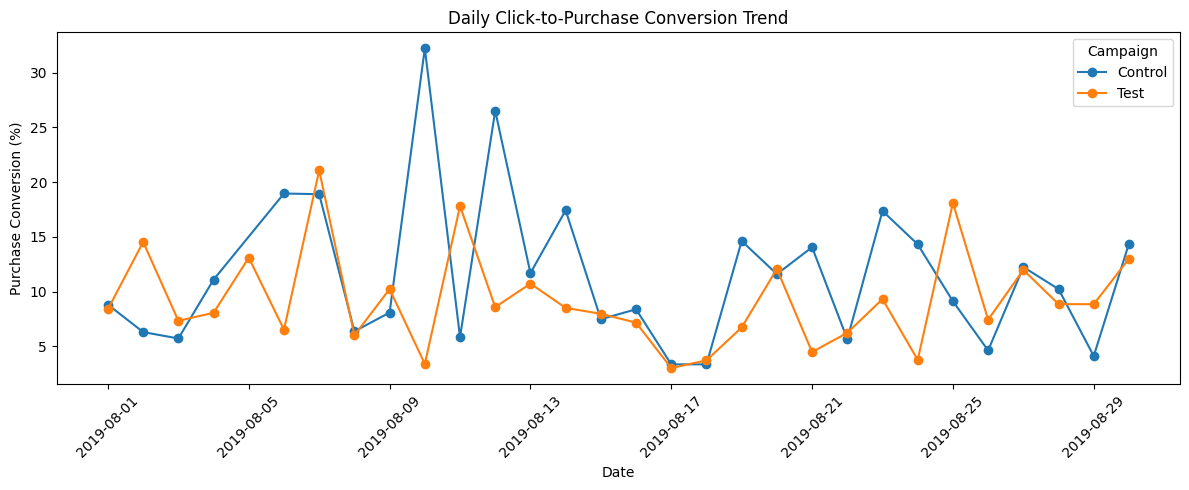

In [184]:
# Daily Purchase Conversion Trend

plt.figure(figsize=(12, 5))

for campaign in ["Control", "Test"]:
    campaign_data = df[
        df["Campaign Type"] == campaign
    ].sort_values("Date")

    plt.plot(
        campaign_data["Date"],
        campaign_data["Purchase Conversion (%)"],
        marker="o",
        label=campaign
    )

plt.title("Daily Click-to-Purchase Conversion Trend")
plt.xlabel("Date")
plt.ylabel("Purchase Conversion (%)")
plt.legend(title="Campaign")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(visuals_folder, "daily_purchase_conversion.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

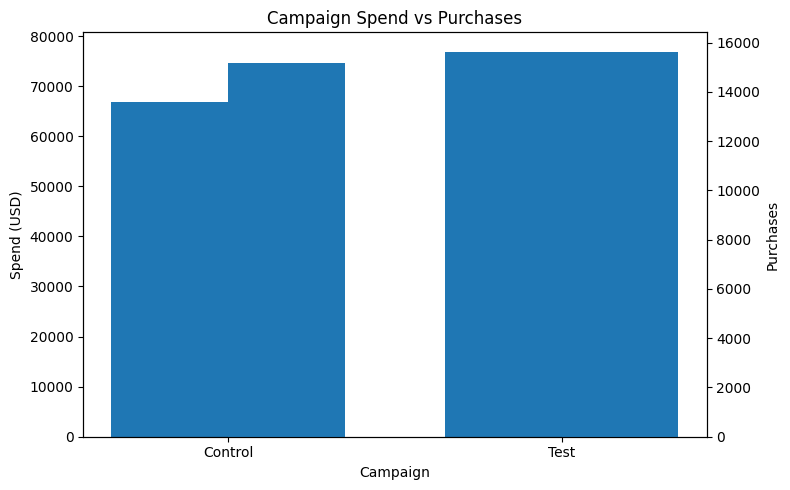

In [185]:
# Spend vs Purchases

spend_purchase = campaign_totals[
    ["Spend [USD]", "# of Purchase"]
].copy()

fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(spend_purchase))
width = 0.35

bars1 = ax1.bar(
    x - width/2,
    spend_purchase["Spend [USD]"],
    width,
    label="Spend"
)

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    spend_purchase["# of Purchase"],
    width,
    label="Purchases"
)

ax1.set_title("Campaign Spend vs Purchases")
ax1.set_xlabel("Campaign")
ax1.set_ylabel("Spend (USD)")
ax2.set_ylabel("Purchases")

ax1.set_xticks(x)
ax1.set_xticklabels(["Control", "Test"])

plt.tight_layout()

plt.savefig(
    os.path.join(visuals_folder, "spend_vs_purchases.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

## Business Recommendation

The Test campaign generated stronger user engagement, with a 66.54% higher CTR and 17.28% more website clicks than the Control campaign. The CTR difference was statistically significant (p = 0.0003).

However, the increase in engagement did not translate into a proportional increase in purchases. Test generated only 3.14% more purchases while requiring 15.08% more spending. Its CPA was 11.57% higher, although the difference was not statistically significant (p = 0.1946).

The funnel analysis shows that Test performed strongly at the Cart-to-Purchase stage but experienced a significant drop at the View-to-Cart stage.

### Recommendation

The Test campaign should not be scaled solely based on its higher CTR. Instead, the business should investigate the View-to-Cart stage and identify why users who click and view content are less likely to add products to their cart.

A practical strategy would be to retain the elements of the Test campaign that successfully generate clicks while improving the post-click experience and conversion journey.

Further testing should focus on landing-page experience, product presentation, offers, and calls-to-action to improve the View-to-Cart conversion rate.

Using Project Source Modules

In [186]:
import sys
import os

# Add the src folder to Python's import path
sys.path.append(os.path.abspath("../src"))

from data_cleaning import load_campaign_data, clean_campaign_data
from metrics import calculate_kpis, campaign_summary
from statistical_testing import welch_ttest, compare_campaigns
from eda import (
    plot_campaign_comparison,
    plot_ctr_comparison,
    plot_cpa_comparison
)

print("All source modules imported successfully!")

All source modules imported successfully!


In [187]:
# Load the raw campaign datasets using data_cleaning.py

control_module, test_module = load_campaign_data(
    "../data/raw/control_group.csv",
    "../data/raw/test_group.csv"
)

print("Control Campaign:", control_module.shape)
print("Test Campaign:", test_module.shape)

Control Campaign: (30, 10)
Test Campaign: (30, 10)


In [188]:
# Clean and combine the datasets using data_cleaning.py

df_module = clean_campaign_data(
    control_module,
    test_module
)

print("Cleaned dataset shape:", df_module.shape)

Cleaned dataset shape: (59, 11)


In [189]:
# Calculate KPIs using metrics.py

df_module = calculate_kpis(df_module)

print("KPI calculation completed.")

display(
    df_module[
        [
            "Campaign Type",
            "Date",
            "CTR (%)",
            "CPC (USD)",
            "CPA (USD)",
            "Purchase Conversion (%)",
            "View to Cart (%)",
            "Cart to Purchase (%)"
        ]
    ].head()
)

KPI calculation completed.


,Campaign Type,Date,CTR (%),CPC (USD),CPA (USD),Purchase Conversion (%),View to Cart (%),Cart to Purchase (%)
0,Control,2019-08-01,8.483471,0.324971,3.689320,8.808438,84.251969,33.974711
1,Control,2019-08-02,6.700264,0.216646,3.438356,6.300863,66.214014,41.919606
2,Control,2019-08-03,4.941121,0.360018,6.298387,5.716042,73.208522,32.804233
3,Control,2019-08-04,4.205659,0.632953,5.705882,11.092985,120.468432,28.740490
4,Control,2019-08-06,3.692838,0.765392,4.035340,18.967229,62.770216,97.448980


In [190]:
# Create campaign summary using metrics.py

summary_module = campaign_summary(df_module)

display(summary_module.round(2))

,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,CTR (%),CPC (USD),CPA (USD),Click to Purchase (%)
Campaign Type,,,,,,,,,,,,
Control,66818,3177233.0,2576503.0,154303.0,64418.0,56370.0,37700.0,15161.0,4.86,0.43,4.41,9.83
Test,76892,2237544.0,1604747.0,180970.0,72569.0,55740.0,26446.0,15637.0,8.09,0.42,4.92,8.64


In [191]:
# Statistical testing using statistical_testing.py

results_module = compare_campaigns(df_module)

for metric, result in results_module.items():
    print(f"\n{metric}")
    print(f"Control Mean: {result['Control Mean']:.4f}")
    print(f"Test Mean:    {result['Test Mean']:.4f}")
    print(f"p-value:      {result['p-value']:.4f}")


CTR (%)
Control Mean: 5.0959
Test Mean:    10.2423
p-value:      0.0003

CPA (USD)
Control Mean: 5.0523
Test Mean:    5.8996
p-value:      0.1946

Purchase Conversion (%)
Control Mean: 11.4772
Test Mean:    9.2312
p-value:      0.1428


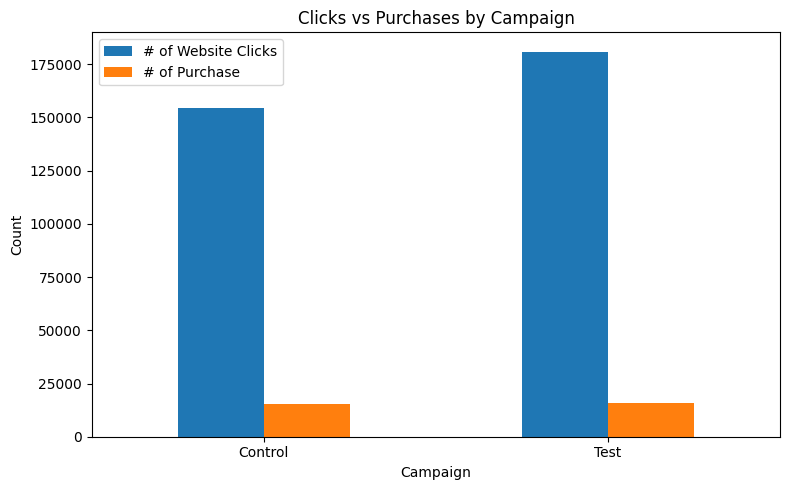

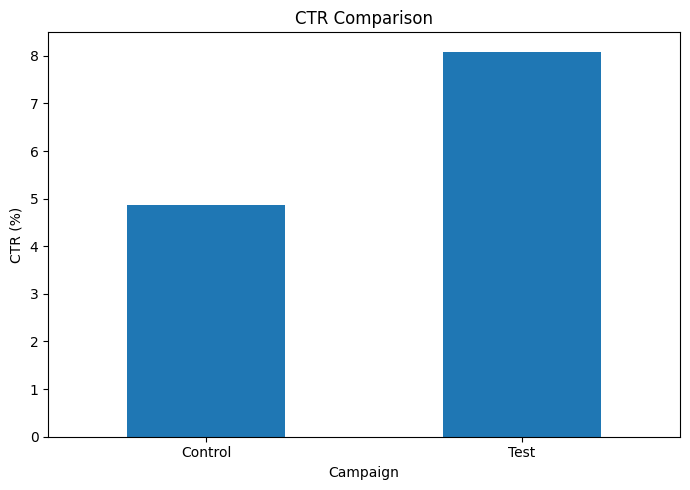

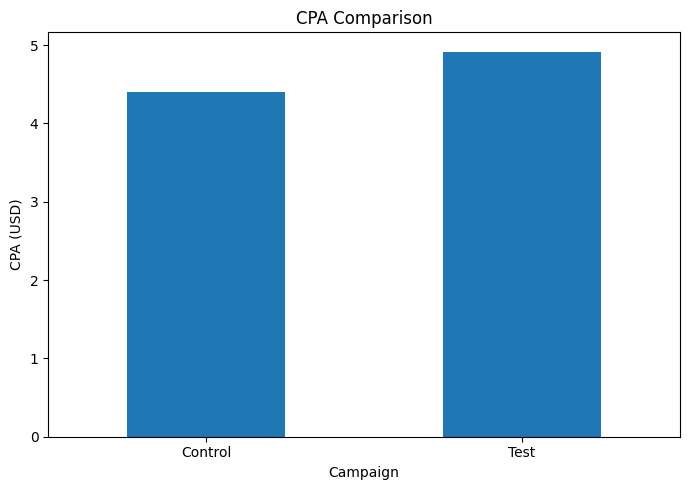

In [192]:
# Use EDA functions from eda.py

plot_campaign_comparison(summary_module)
plot_ctr_comparison(summary_module)
plot_cpa_comparison(summary_module)